In [1]:
import sys
sys.path.append("../src")
# from linear_foraging import foraging_playground_linear
import numpy as np
# from foraging_utils import optimal_linear, chance_linear, register_custom_env
import matplotlib.pyplot as plt
import gymnasium as gym
import pickle
from matplotlib.ticker import MultipleLocator
import os
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
import torch.nn as nn
import torch
import pandas as pd
from sklearn.preprocessing import OneHotEncoder
from utils import time_embedding_np, reward_simulate,simulate_data_raw,make_weighted_target,position_encoder
from utils import best_next_state,path_opt,preward_opt,compute_normalized_future_rewards
import xgboost as xgb
from scipy.stats import truncnorm

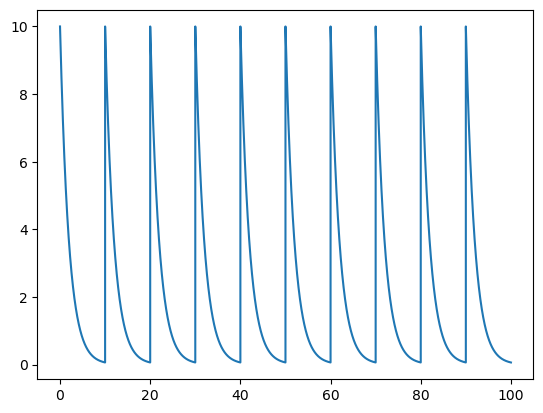

In [2]:
def reward_simulate(state, t,rewards_in_period):
    # print(state)
    phase = t % 20
    if 1 <= state < 2 and phase < 10:
        val = 10 * (0.6 ** phase)
    elif 5<= state < 6  and phase >= 10:
        val = 10 * (0.6 ** (phase-10))
    else:
        val = 0.0
    return float(val)  

def step_at_bounds(state, action, size=7):
    candidate = state + action
    # If candidate goes out of bounds, stay; else move.
    if (candidate < 0).any() or (candidate >= size).any():
        return state.copy()
    return candidate

def simulate_data_count(rewards_in_period,delta,session_duration = 10000,tdim=50, n_sessions=1,seed  = 515):
    """
    Simulate training and testing data with rewards from a given environment.


    Returns:
    - actions, state, ireward, times: np.ndarrays
    """

    np.random.seed(seed)
    actions, states, irewards,times = [], [], [], []
    # state_initial = int(np.random.choice(np.arange(7)))
    state_initial = 1
    for episode in range(n_sessions):
        t = 0
        episode_data = []
        state = state_initial
        for _ in range(session_duration):
            ireward = reward_simulate(state, t, rewards_in_period)
            # print(len(state))
            state_vec = np.array([state]).reshape(1,1)  # shape (1, state_dim)
            time_emb = time_embedding_np(t+1, tdim=tdim).reshape(1,tdim)
            # print(state_vec.shape,time_emb.shape)
            features = np.hstack([state_vec, time_emb])
            ACTIONS = np.array([[-delta],[0],[delta]])
            idx = np.random.randint(len(ACTIONS))
            action = ACTIONS[idx] # up,down, left right
            next_state = step_at_bounds(state, action, size=7)
            # print(next_state)
            episode_data.append((action,features,ireward))
            state = next_state
            t += delta
        for i, (action, features, ireward) in enumerate(episode_data):
            actions.append(action)
            states.append(features)
            irewards.append(ireward)
            times.append(i*delta)

    return (
        np.array(actions),
        np.array(states),
        np.array(irewards),
        np.array(times),
    )

# Time Embedding with absolute time
def time_embedding_np(t, tdim=50):
    freqs = (2 * np.pi) / np.arange(2, tdim + 1, 2)  # shape: (tdim//2,)
    angles = np.outer(t, freqs)
    sin_emb = np.sin(angles)
    cos_emb = np.cos(angles)
    emb = np.concatenate([sin_emb, cos_emb], axis=-1)  # shape: (len(t), tdim)
    if emb.shape[0] == 1:
        return emb[0]  # return (tdim,) for scalar input
    return emb


total_times = 5000
base_reward = 10.0
decay_rate = 0.6
reward_period = 10 

rewards_in_period = []
time_in_periods = []
for period_start in range(0, total_times, reward_period):
    period_end = min(period_start + reward_period, total_times)
    steps_in_period = np.arange(period_start, period_end, 0.001)
    time_in_periods.extend(steps_in_period)
    rewards_in_period.extend(base_reward * (decay_rate ** (steps_in_period - period_start)))
plt.plot(time_in_periods[:100000],rewards_in_period[:100000])

# Verify the simulation enviroment

[0.6478 0.6944 0.9508 ... 0.219  0.3141 0.1728]
[1.1375 1.6075 1.3807 ... 1.608  1.3864 1.772 ]
[2.0176 2.7066 2.6045 ... 2.342  2.7573 2.3047]
[3.3211 3.2979 3.0733 ... 3.9953 3.154  3.2856]
[4.4099 4.1465 4.7704 ... 4.0376 4.6514 4.1339]
[5.6088 5.3062 5.4826 ... 5.0935 5.6849 5.4024]


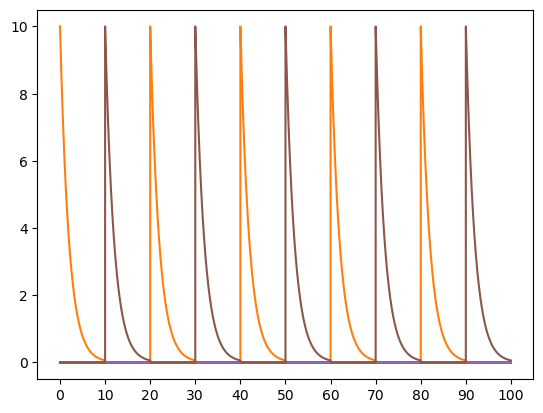

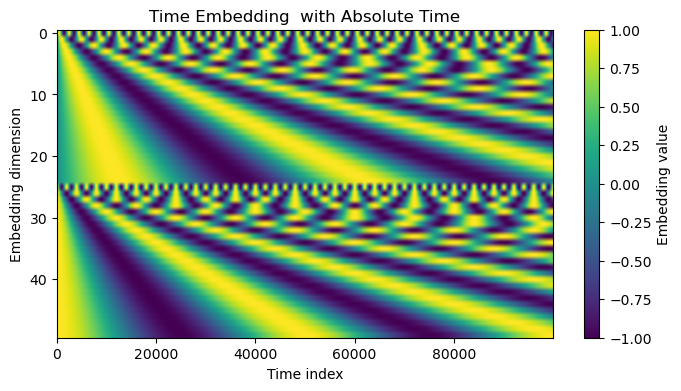

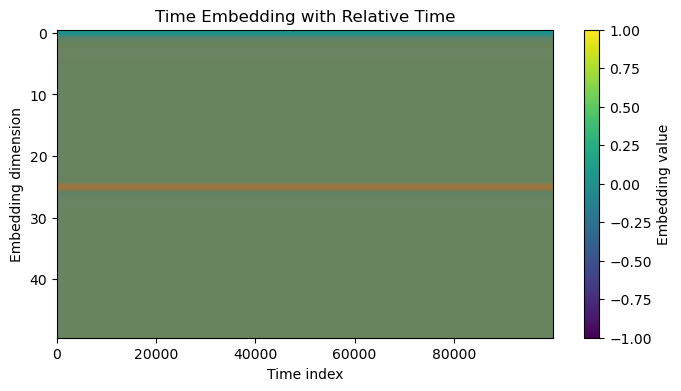

In [89]:
T = 100
delta = 0.001
for i in range(6):
    state_raw = np.random.choice(np.arange(i,i+1,0.0001),size = int(T/delta))
    print(state_raw)
    time_raw = np.arange(0,100,delta)
    reward = [reward_simulate(state_raw[i],time_raw[i],rewards_in_period) for i in range(len(state_raw))]
    plt.plot(time_raw,reward)
plt.xticks(np.arange(0,110,10))
plt.show()


## time embedding with raw time
time_emb = time_embedding_np(time_raw)
plt.figure(figsize=(8, 4))                
plt.imshow(time_emb.T, aspect='auto',        
           cmap='viridis',                 
           vmin=time_emb.min(),            
           vmax=time_emb.max())           
plt.colorbar(label='Embedding value')      
plt.title("Time Embedding  with Absolute Time")
plt.ylabel("Embedding dimension")
plt.xlabel("Time index")
plt.show()

## time embedding with relative time
time_emb = time_embedding_np(np.arange(0,len(time_raw),1))
plt.figure(figsize=(8, 4))                
plt.imshow(time_emb.T, aspect='auto',        
           cmap='viridis',                
           vmin=time_emb.min(),           
           vmax=time_emb.max())            
plt.colorbar(label='Embedding value')      
plt.title("Time Embedding with Relative Time")
plt.ylabel("Embedding dimension")
plt.xlabel("Time index")
plt.show()

# Randomly sample from distribution - Proforg-I

Text(0, 0.5, '# of samples')

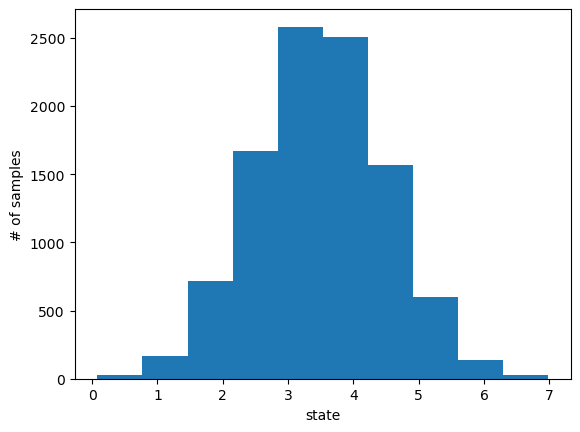

In [70]:
n = 10000
delta = 0.3
T= int(n*delta)
lower, upper = 0, 7
mu, sigma = 3.5, 1
a, b = (lower - mu) / sigma, (upper - mu) / sigma
state_raw =truncnorm.rvs(a, b, loc=mu, scale=sigma, size=n).reshape(-1,1)
time_raw = np.random.choice([i for i in np.arange(0,T,delta)],size = n)
irewards = [reward_simulate(state_raw[i],time_raw[i],rewards_in_period) for i in range(len(state_raw))]
plt.hist(state_raw)
plt.xlabel('state')
plt.ylabel('# of samples')
# plt.hist(irewards)


In [71]:
time_emb = time_embedding_np([i+1 for i in time_raw])
state_pe = np.hstack([state_raw,time_emb])
gamma = 0.9

X_train_oh = state_pe[:n,:]
Y_train_action = irewards[:n]

rf_action = xgb.XGBRegressor(
objective="reg:squarederror",
tree_method="exact", 
n_jobs = -1,
learning_rate=0.05, max_depth=10,
subsample=1, colsample_bytree=0.8,
n_estimators=2000, eval_metric="rmse")
rf_action.fit(X_train_oh, Y_train_action)



XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric='rmse', feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=10,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=2000,
             n_jobs=-1, num_parallel_tree=None, ...)

In [56]:
def get_candidates(state,t,delta):
    next_state = [state-delta, state, state+delta]
    if next_state[0] < 0 :
        return [state+delta, 0]
    elif next_state[-1] > 7:
        return [state-delta, state]
    else:
        return next_state

def enumerate_paths_cont(x0, t_initial = 0, t_prime=20,delta= 0.001):
    paths = [[x0]]
    for t in range(t_prime):
        new_paths = []
        for path in paths:
            curr = path[-1]
            for nxt in get_candidates(curr,t,delta):
                new_paths.append(path + [nxt])
        paths = new_paths
    
    # Convert to DataFrame: each row is one path, columns t=0..T
    cols = [f"t={t_initial+i}" for i in range(t_prime+1)]
    df = pd.DataFrame(paths, columns=cols)
    return df

In [77]:
step_prime = 12
t_prime = step_prime * delta
T = 3000+20
current_state = truncnorm.rvs(a, b, loc=mu, scale=sigma, size=1).reshape(-1,1).item()
print(T,current_state)
future_states = [current_state]
for delta_t in np.arange(0,40,delta):
    df_all_paths = enumerate_paths_cont(x0=current_state,t_initial = T+delta_t,t_prime = step_prime,delta = delta)
    n_paths = df_all_paths.shape[0]
    irewards_pred = np.zeros((n_paths,  step_prime+1))

    for i in np.arange(0,t_prime+delta,delta):
        i_idx = int(i/delta)
        next_state = np.array(df_all_paths.iloc[:,i_idx]).reshape(-1,1)
        curr_time = T+delta_t+i+1
        time_emb = time_embedding_np(np.ones(next_state.shape[0])*curr_time, tdim=50)
        features = np.hstack([next_state,time_emb])
        irewards_pred[:,i_idx] = rf_action.predict(features)
    # # Convert to DataFrame for inspection
    reward_cols = [f"t={T+delta_t+t}" for t in np.arange(0,t_prime+delta,delta)]
    df_ireward = pd.DataFrame(irewards_pred, columns=reward_cols)
    rewards_matrix = df_ireward.iloc[:, 1:].values  # shape (n_paths, T)
    discounts = gamma ** np.arange(1, step_prime+1)

    # Compute discounted total reward per path
    discounted_returns = rewards_matrix * discounts  
    total_discounted = discounted_returns.sum(axis=1)
    # print(total_discounted)
    bext_idx = np.argmax(total_discounted)
    next_state = df_all_paths.iloc[bext_idx,1].item()
    future_states.append(next_state)
    current_state = next_state
    print(T+delta_t+1,current_state)

3020 4.138875442108074
3021.0 3.8388754421080744
3021.3 3.5388754421080746
3021.6 3.2388754421080748
3021.9 2.938875442108075
3022.2 2.638875442108075
3022.5 2.3388754421080753
3022.8 2.0388754421080755
3023.1 1.7388754421080754
3023.4 1.7388754421080754
3023.7 1.4388754421080754
3024.0 1.7388754421080754
3024.3 1.7388754421080754
3024.6 1.7388754421080754
3024.9 1.7388754421080754
3025.2 1.7388754421080754
3025.5 1.7388754421080754
3025.8 1.7388754421080754
3026.1 1.4388754421080754
3026.4 1.1388754421080753
3026.7 1.1388754421080753
3027.0 1.1388754421080753
3027.3 1.4388754421080754
3027.6 1.7388754421080754
3027.9 2.0388754421080755
3028.2 2.3388754421080753
3028.5 2.638875442108075
3028.8 2.938875442108075
3029.1 3.2388754421080748
3029.4 3.5388754421080746
3029.7 3.8388754421080744
3030.0 4.138875442108074
3030.3 4.438875442108074
3030.6 4.738875442108074
3030.9 5.038875442108074
3031.2 5.3388754421080735
3031.5 5.3388754421080735
3031.8 5.638875442108073
3032.1 5.638875442108073

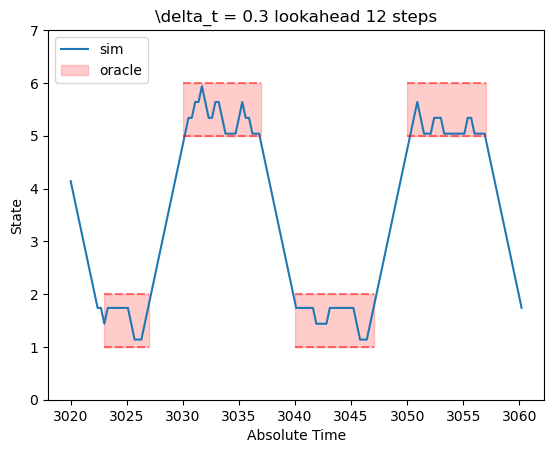

In [80]:
T = 3020
plt.plot(np.arange(T,T+40+delta,delta),future_states,label = 'sim')
plt.xticks(np.arange(T,T+40+5,5))
plt.fill_between(np.arange(3030,3038,1),np.ones(8)*5,np.ones(8)*6,color = 'red',alpha = 0.2,label = 'oracle')
plt.fill_between(np.arange(3050,3058,1),np.ones(8)*5,np.ones(8)*6,color = 'red',alpha = 0.2)
plt.fill_between(np.arange(3023,3028,1),np.ones(5)*1,np.ones(5)*2,color = 'red',alpha = 0.2)
plt.fill_between(np.arange(3040,3048,1),np.ones(8)*1,np.ones(8)*2,color = 'red',alpha = 0.2)
plt.hlines(y = 6, xmin = 3030, xmax = 3037,color = 'r',linestyles= '--',alpha = 0.5)
plt.hlines(y = 5, xmin = 3030, xmax = 3037,color = 'r',linestyles= '--',alpha = 0.5)
plt.hlines(y = 6, xmin = 3050, xmax = 3057,color = 'r',linestyles= '--',alpha = 0.5)
plt.hlines(y = 5, xmin = 3050, xmax = 3057,color = 'r',linestyles= '--',alpha = 0.5)
plt.hlines(y = 1, xmin = 3023, xmax = 3027,color = 'r',linestyles= '--',alpha = 0.5)
plt.hlines(y = 2, xmin = 3023, xmax = 3027,color = 'r',linestyles= '--',alpha = 0.5)
plt.hlines(y = 1, xmin = 3040, xmax = 3047,color = 'r',linestyles= '--',alpha = 0.5)
plt.hlines(y = 2, xmin = 3040, xmax = 3047,color = 'r',linestyles= '--',alpha = 0.5)
plt.yticks([0,1,2,3,4,5,6,7])
plt.xlabel('Absolute Time')
plt.ylabel('State')
plt.title('\delta_t = 0.3 lookahead 12 steps')
plt.legend()

# Single Episodec - ProForg

(100000, 1, 51) (100000,)


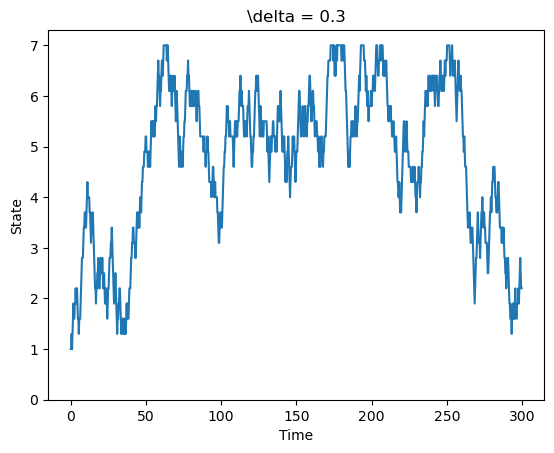

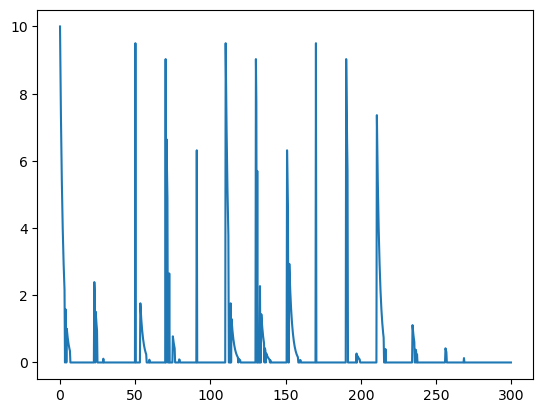

In [46]:
actions, states, irewards, times = simulate_data_count(rewards_in_period,0.3,session_duration = 10000,tdim=50, n_sessions=10,seed  = 515)
print(states.shape, times.shape)
plt.plot(times[:1000],states[:1000,0,0])
plt.xlabel('Time')
plt.ylabel('State')
plt.title('\delta = 0.3')
plt.yticks([0,1,2,3,4,5,6,7])
plt.show()
plt.plot(times[:1000],irewards[:1000])

In [127]:
gamma = 0.9

T = 10000
delta = 0.5
n= int(T/delta)
print(n)
seed = np.random.choice(np.arange(0,100),size = 1)
actions, states, irewards, times = simulate_data_count(rewards_in_period,delta,
                                                       session_duration = 50000,tdim=50, 
                                                       n_sessions=1,seed = 515+seed)
prewards = make_weighted_target(irewards, gamma,T = n,normalization = False)
X_train_oh = states[:n,0,:]
Y_train_action = irewards[:n]
Y_train_value = prewards[:n]

rf_value = xgb.XGBRegressor(
    objective="reg:squarederror",
    tree_method="exact", 
    n_jobs = -1,
    learning_rate=0.05, max_depth=10,
    subsample=1, colsample_bytree=0.8,
    n_estimators=2000, eval_metric="rmse")
rf_value.fit(X_train_oh, Y_train_value)

rf_action = xgb.XGBRegressor(
    objective="reg:squarederror",
    tree_method="exact", 
    n_jobs = -1,
    learning_rate=0.05, max_depth=10,
    subsample=1, colsample_bytree=0.8,
    n_estimators=2000, eval_metric="rmse")
rf_action.fit(X_train_oh, Y_train_action)



20000


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric='rmse', feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=10,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=2000,
             n_jobs=-1, num_parallel_tree=None, ...)

In [156]:
step_prime = 10
t_prime = step_prime * delta
T = T+20
DELTA_T = 40
current_state = states[T,0,0]/10
print(T,current_state)
future_states = [current_state]
for delta_t in np.arange(0,DELTA_T,delta):
    df_all_paths = enumerate_paths_cont(x0=current_state,t_initial = T+delta_t,t_prime = step_prime,delta = delta)
    n_paths = df_all_paths.shape[0]
    irewards_pred = np.zeros((n_paths,  step_prime+1))

    for i in np.arange(0,round(t_prime+delta,3),delta):
        i_idx = int(i/delta)
        # print(i_idx)
        next_state = np.array(df_all_paths.iloc[:,i_idx]).reshape(-1,1)
        curr_time = T+delta_t+i+1
        time_emb = time_embedding_np(np.ones(next_state.shape[0])*curr_time, tdim=50)
        features = np.hstack([next_state,time_emb])
        irewards_pred[:,i_idx] = rf_action.predict(features)
    # # Convert to DataFrame for inspection
    reward_cols = [f"t={T+delta_t+t}" for t in np.arange(0,round(t_prime+delta,3),delta)]
    df_ireward = pd.DataFrame(irewards_pred, columns=reward_cols)
    next_state = np.array(df_all_paths.iloc[:,-1]).reshape(-1,1)
    curr_time = T+1+t_prime
    time_emb = time_embedding_np(np.ones(next_state.shape[0])*curr_time, tdim=50)
    # print(next_state.shape,time_emb.shape)
    features = np.hstack([next_state,time_emb])
    prewards_pred = rf_value.predict(features)
    df_ireward[f"preward"] = prewards_pred
    rewards_matrix = df_ireward.iloc[:, 1:].values
    discounts = gamma ** np.arange(0, step_prime+1)

    # Compute discounted total reward per path
    discounted_returns = rewards_matrix * discounts  
    total_discounted = discounted_returns.sum(axis=1)
    # print(total_discounted)
    bext_idx = np.argmax(total_discounted)
    next_state = df_all_paths.iloc[bext_idx,1].item()
    future_states.append(next_state)
    current_state = next_state
    print(T+delta_t+delta,current_state)


10060 4.100000000000002
10060.1 4.100000000000002
10060.2 4.100000000000002
10060.300000000001 4.100000000000002
10060.4 4.100000000000002
10060.5 4.200000000000002
10060.6 4.300000000000002
10060.7 4.400000000000001
10060.800000000001 4.500000000000001
10060.9 4.6000000000000005


KeyboardInterrupt: 

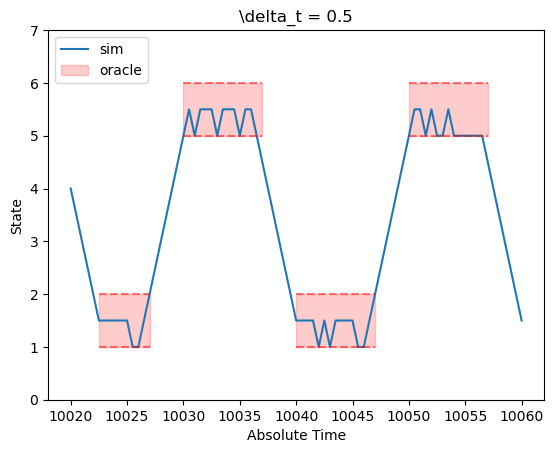

In [131]:
plt.plot(np.arange(T,T+DELTA_T+delta,delta),future_states,label = 'sim')
plt.xticks(np.arange(T,T+DELTA_T+5,5))
plt.fill_between(np.arange(10030,10038,1),np.ones(8)*5,np.ones(8)*6,color = 'red',alpha = 0.2,label = 'oracle')
plt.fill_between(np.arange(10050,10058,1),np.ones(8)*5,np.ones(8)*6,color = 'red',alpha = 0.2)
plt.fill_between(np.arange(10022.5,10027.5,0.5),np.ones(10)*1,np.ones(10)*2,color = 'red',alpha = 0.2)
plt.fill_between(np.arange(10040,10047.5,0.5),np.ones(15)*1,np.ones(15)*2,color = 'red',alpha = 0.2)
plt.hlines(y = 6, xmin = 10030, xmax = 10037,color = 'r',linestyles= '--',alpha = 0.5)
plt.hlines(y = 5, xmin = 10030, xmax = 10037,color = 'r',linestyles= '--',alpha = 0.5)
plt.hlines(y = 6, xmin = 10050, xmax = 10057,color = 'r',linestyles= '--',alpha = 0.5)
plt.hlines(y = 5, xmin = 10050, xmax = 10057,color = 'r',linestyles= '--',alpha = 0.5)
plt.hlines(y = 1, xmin = 10022.5, xmax = 10027,color = 'r',linestyles= '--',alpha = 0.5)
plt.hlines(y = 2, xmin = 10022.5, xmax = 10027,color = 'r',linestyles= '--',alpha = 0.5)
plt.hlines(y = 1, xmin = 10040, xmax = 10047,color = 'r',linestyles= '--',alpha = 0.5)
plt.hlines(y = 2, xmin = 10040, xmax = 10047,color = 'r',linestyles= '--',alpha = 0.5)
plt.yticks([0,1,2,3,4,5,6,7])
plt.xlabel('Absolute Time')
plt.ylabel('State')
plt.title('\delta_t = 0.5')
plt.legend()

# smaller delta

In [30]:
gamma = 0.90
T = 3000
delta = 0.2
n= int(T/delta)
print(n)
seed = np.random.choice(np.arange(0,100),size = 1)
actions, states, irewards, times = simulate_data_count(rewards_in_period,delta,
                                                       session_duration = 500000,tdim=50, 
                                                       n_sessions=1,seed = 515+seed)

prewards = make_weighted_target(irewards, gamma,T = n,normalization = False)
X_train_oh = states[:n,0,:]
# X_train_oh = np.hstack([position_encoder(states[:n,0,0], type="onehot"), states[:n,0,1:]])
print(X_train_oh.shape)
Y_train_action = irewards[:n]
Y_train_value = prewards[:n]

rf_value = xgb.XGBRegressor(
    objective="reg:squarederror",
    tree_method="exact", 
    n_jobs = -1,
    learning_rate=0.05, max_depth=10,
    subsample=1, colsample_bytree=0.8,
    n_estimators=2000, eval_metric="rmse")
rf_value.fit(X_train_oh, Y_train_value)

rf_action = xgb.XGBRegressor(
    objective="reg:squarederror",
    tree_method="exact", 
    n_jobs = -1,
    learning_rate=0.05, max_depth=10,
    subsample=1, colsample_bytree=0.8,
    n_estimators=2000, eval_metric="rmse")
rf_action.fit(X_train_oh, Y_train_action)


15000
(15000, 51)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric='rmse', feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=10,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=2000,
             n_jobs=-1, num_parallel_tree=None, ...)

In [35]:
step_prime = 14
delta = 0.2
t_prime = step_prime * delta
T = 3000+20
DELTA_T = 20
current_state = states[T,0,0]
print(T,current_state)
future_states = [current_state]
for delta_t in np.arange(0,DELTA_T,delta):
    df_all_paths = enumerate_paths_cont(x0=current_state,t_initial = T+delta_t,t_prime = step_prime,delta = delta)
    n_paths = df_all_paths.shape[0]
    irewards_pred = np.zeros((n_paths,  step_prime+1))

    for i in np.arange(0,round(t_prime+delta,3),delta):
        i_idx = int(i/delta)
        # print(i_idx)
        next_state = np.array(df_all_paths.iloc[:,i_idx]).reshape(-1,1)
        curr_time = T+delta_t+i+1
        time_emb = time_embedding_np(np.ones(next_state.shape[0])*curr_time, tdim=50)
        features = np.hstack([next_state,time_emb])
        # np.hstack([position_encoder(next_state, type="onehot"), time_emb])
        # np.hstack([next_state,time_emb])
        irewards_pred[:,i_idx] = rf_action.predict(features)
    # # Convert to DataFrame for inspection
    reward_cols = [f"t={T+delta_t+t}" for t in np.arange(0,round(t_prime+delta,3),delta)]
    df_ireward = pd.DataFrame(irewards_pred, columns=reward_cols)
    next_state = np.array(df_all_paths.iloc[:,-1]).reshape(-1,1)
    curr_time = T+1+t_prime
    time_emb = time_embedding_np(np.ones(next_state.shape[0])*curr_time, tdim=50)
    # print(next_state.shape,time_emb.shape)
    features = np.hstack([next_state,time_emb])
    # np.hstack([position_encoder(next_state, type="onehot"), time_emb])
    # np.hstack([next_state,time_emb])
    prewards_pred = rf_value.predict(features)
    df_ireward[f"preward"] = prewards_pred
    rewards_matrix = df_ireward.iloc[:, 1:].values
    discounts = gamma ** np.arange(0, step_prime+1)

    # Compute discounted total reward per path
    discounted_returns = rewards_matrix * discounts  
    total_discounted = discounted_returns.sum(axis=1)
    # print(total_discounted)
    bext_idx = np.argmax(total_discounted)
    next_state = df_all_paths.iloc[bext_idx,1].item()
    future_states.append(next_state)
    current_state = next_state
    print(T+delta_t+delta,current_state)


3020 6.800000000000003
3020.2 6.600000000000003
3020.3999999999996 6.400000000000003
3020.6 6.200000000000003
3020.7999999999997 6.000000000000003
3021.0 5.8000000000000025
3021.2 5.600000000000002
3021.3999999999996 5.400000000000002
3021.6 5.200000000000002
3021.7999999999997 5.000000000000002
3022.0 4.800000000000002
3022.2 4.600000000000001
3022.3999999999996 4.400000000000001
3022.6 4.200000000000001


KeyboardInterrupt: 

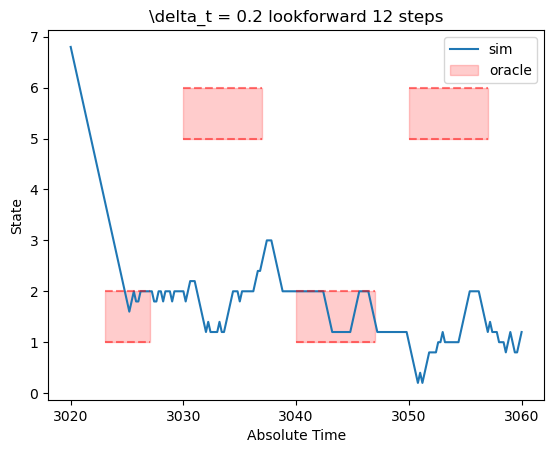

In [34]:
plt.plot(np.arange(T,T+DELTA_T+delta,delta),future_states,label = 'sim')
plt.xticks(np.arange(T,T+DELTA_T+10,10))
plt.fill_between(np.arange(3030,3038,1),np.ones(8)*5,np.ones(8)*6,color = 'red',alpha = 0.2,label = 'oracle')
plt.fill_between(np.arange(3050,3058,1),np.ones(8)*5,np.ones(8)*6,color = 'red',alpha = 0.2)
# plt.fill_between(np.arange(30070,30078,1),np.ones(8)*5,np.ones(8)*6,color = 'red',alpha = 0.2)
plt.fill_between(np.arange(3023,3028,1),np.ones(5)*1,np.ones(5)*2,color = 'red',alpha = 0.2)
plt.fill_between(np.arange(3040,3048,1),np.ones(8)*1,np.ones(8)*2,color = 'red',alpha = 0.2)
# plt.fill_between(np.arange(30060,30068,1),np.ones(8)*1,np.ones(8)*2,color = 'red',alpha = 0.2)
plt.hlines(y = 6, xmin = 3030, xmax = 3037,color = 'r',linestyles= '--',alpha = 0.5)
plt.hlines(y = 5, xmin = 3030, xmax = 3037,color = 'r',linestyles= '--',alpha = 0.5)
plt.hlines(y = 6, xmin = 3050, xmax = 3057,color = 'r',linestyles= '--',alpha = 0.5)
plt.hlines(y = 5, xmin = 3050, xmax = 3057,color = 'r',linestyles= '--',alpha = 0.5)
# plt.hlines(y = 5, xmin = 30070, xmax = 30077,color = 'r',linestyles= '--',alpha = 0.5)
plt.hlines(y = 1, xmin = 3023, xmax = 3027,color = 'r',linestyles= '--',alpha = 0.5)
plt.hlines(y = 2, xmin = 3023, xmax = 3027,color = 'r',linestyles= '--',alpha = 0.5)
plt.hlines(y = 1, xmin = 3040, xmax = 3047,color = 'r',linestyles= '--',alpha = 0.5)
plt.hlines(y = 2, xmin = 3040, xmax = 3047,color = 'r',linestyles= '--',alpha = 0.5)
# plt.hlines(y = 2, xmin = 30060, xmax = 30067,color = 'r',linestyles= '--',alpha = 0.5)
plt.yticks([0,1,2,3,4,5,6,7])
plt.xlabel('Absolute Time')
plt.ylabel('State')
plt.title('\delta_t = 0.2 lookforward 12 steps')
plt.legend()

# Single Episode + Greedy Search

In [81]:
gamma = 0.90
T = 3000
delta = 0.01
n= int(T/delta)
print(n)
seed = np.random.choice(np.arange(0,100),size = 1)
actions, states, irewards, times = simulate_data_count(rewards_in_period,delta,
                                                       session_duration = 500000,tdim=50, 
                                                       n_sessions=1,seed = 515+seed)

prewards = make_weighted_target(irewards, gamma,T = n,normalization = False)
X_train_oh = states[:n,0,:]
# X_train_oh = np.hstack([position_encoder(states[:n,0,0], type="onehot"), states[:n,0,1:]])
print(X_train_oh.shape)
Y_train_action = irewards[:n]
Y_train_value = prewards[:n]

rf_value = xgb.XGBRegressor(
    objective="reg:squarederror",
    tree_method="exact", 
    n_jobs = -1,
    learning_rate=0.05, max_depth=10,
    subsample=1, colsample_bytree=0.8,
    n_estimators=2000, eval_metric="rmse")
rf_value.fit(X_train_oh, Y_train_value)

rf_action = xgb.XGBRegressor(
    objective="reg:squarederror",
    tree_method="exact", 
    n_jobs = -1,
    learning_rate=0.05, max_depth=10,
    subsample=1, colsample_bytree=0.8,
    n_estimators=2000, eval_metric="rmse")
rf_action.fit(X_train_oh, Y_train_action)


300000
(300000, 51)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric='rmse', feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=10,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=2000,
             n_jobs=-1, num_parallel_tree=None, ...)

In [205]:
t_prime_value = 700
delta = 0.01
current_state = states[T,0,0]
next_state = np.arange(current_state-t_prime_value*delta,current_state+t_prime_value*delta,delta).reshape(-1,1)
next_state = np.clip(next_state, 0, 7, out=next_state)
curr_time = T+1+t_prime_value*delta
print(curr_time-1)
print(min(next_state),max(next_state))
time_emb = time_embedding_np(np.ones(next_state.shape[0])*curr_time, tdim=50)
features = np.hstack([next_state,time_emb])
score_value = rf_value.predict(features)
score_action = rf_action.predict(features)
score = score_action+score_value
bext_idx_value = np.argmax(score)
best_at_t = next_state[bext_idx_value]
print(bext_idx_value,best_at_t)



3007.0
[0.] [7.]
916 [5.36]


0.6199999999999997
3051.0 [0.96]
3050.98 [5.52]
3050.96 [5.4604]
3050.94 [5.4612]
3050.92 [5.4224]


/var/folders/7_/9pm8yyb11yl_smkwv7tk0ysc0000gn/T/ipykernel_889/2986581442.py:25: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  states_prev = np.arange(current_state-(curr_time-1)*delta,current_state+(curr_time-1)*delta,delta).reshape(-1,1)


3050.9 [5.384]
3050.88 [5.526]
3050.86 [5.3884]
3050.84 [5.3912]
3050.82 [5.3944]
3050.8 [5.458]
3050.7799999999997 [5.462]
3050.7599999999998 [5.3864]
3050.74 [5.3912]
3050.72 [5.3164]
3050.7 [5.322]
3050.68 [5.388]
3050.66 [5.4744]
3050.64 [5.3212]
3050.62 [5.5484]
3050.6 [5.536]
3050.58 [5.544]
3050.56 [5.5324]
3050.54 [5.5412]
3050.52 [5.5304]
3050.5 [5.54]
3050.48 [5.53]
3050.46 [5.5404]
3050.44 [5.5312]
3050.42 [5.5424]
3050.4 [5.534]
3050.38 [5.546]
3050.3599999999997 [5.5184]
3050.3399999999997 [5.5312]
3050.3199999999997 [5.5444]
3050.2999999999997 [5.518]
3050.2799999999997 [5.532]
3050.2599999999998 [5.5264]
3050.24 [5.5212]
3050.22 [5.5164]
3050.2 [5.532]
3050.18 [5.528]
3050.16 [5.5244]
3050.14 [5.5212]
3050.12 [5.3584]
3050.1 [5.516]
3050.08 [5.534]
3050.06 [5.5324]
3050.04 [5.5112]
3050.02 [5.4704]
3050.0 [5.49]
3049.98 [5.47]
3049.96 [5.5104]
3049.94 [5.5112]
3049.9199999999996 [5.5124]
3049.8999999999996 [5.514]
3049.8799999999997 [5.516]
3049.8599999999997 [5.4584]
30

Text(0, 0.5, 'State')

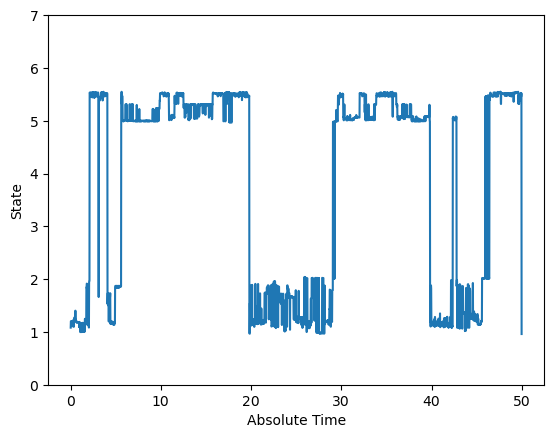

In [85]:
# Backward
t_prime_value = 50
delta = 0.02
current_state = states[T,0,0]
print(current_state)
terminal_state = np.arange(current_state-t_prime_value*delta,current_state+t_prime_value*delta,delta).reshape(-1,1)
terminal_state = np.clip(terminal_state, 0, 7, out=terminal_state)
best_prev = []
states_prev = terminal_state
for t in np.arange(t_prime_value,delta,-delta):
    curr_time = T+1+t
    # print(curr_time)
    time_emb = time_embedding_np(np.ones(states_prev.shape[0])*curr_time, tdim=50)
    features = np.hstack([states_prev,time_emb])
    score_value = rf_value.predict(features)
    score_action = rf_action.predict(features)
    score = score_action+score_value
    bext_idx_value = np.argmax(score)
    best_at_t = states_prev[bext_idx_value]
    best_prev.append(best_at_t)
    print(curr_time,best_at_t)
    # print(score)
    current_state = best_at_t
    # states_prev = np.array([current_state-delta,current_state,current_state+delta]).reshape(-1,1)
    states_prev = np.arange(current_state-(curr_time-1)*delta,current_state+(curr_time-1)*delta,delta).reshape(-1,1)
    # print(states_prev.shape)
    states_prev = np.clip(states_prev, 0, 7, out=states_prev)
plt.plot(np.arange(delta,t_prime_value,delta),list(reversed(best_prev)))
plt.yticks([0,1,2,3,4,5,6,7])
plt.xlabel('Absolute Time')
plt.ylabel('State')

0.6199999999999997
3051.0 [0.96]
3050.98 [0.94]
3050.96 [0.94]
3050.94 [0.96]
3050.92 [0.98]
3050.9 [0.98]
3050.88 [0.98]
3050.86 [1.]
3050.84 [1.02]
3050.82 [1.]
3050.8 [1.]
3050.7799999999997 [1.]
3050.7599999999998 [1.02]
3050.74 [1.02]
3050.72 [1.02]
3050.7 [1.02]
3050.68 [1.02]
3050.66 [1.02]
3050.64 [1.02]
3050.62 [1.02]
3050.6 [1.02]
3050.58 [1.02]
3050.56 [1.02]
3050.54 [1.02]
3050.52 [1.02]
3050.5 [1.02]
3050.48 [1.02]
3050.46 [1.02]
3050.44 [1.02]
3050.42 [1.02]
3050.4 [1.]
3050.38 [1.02]
3050.3599999999997 [1.02]
3050.3399999999997 [1.02]
3050.3199999999997 [1.]
3050.2999999999997 [1.02]
3050.2799999999997 [1.02]
3050.2599999999998 [1.02]
3050.24 [1.02]
3050.22 [1.04]
3050.2 [1.06]
3050.18 [1.08]
3050.16 [1.1]
3050.14 [1.12]
3050.12 [1.14]
3050.1 [1.14]
3050.08 [1.14]
3050.06 [1.14]
3050.04 [1.14]
3050.02 [1.14]
3050.0 [1.14]
3049.98 [1.16]
3049.96 [1.18]
3049.94 [1.18]
3049.9199999999996 [1.18]
3049.8999999999996 [1.18]
3049.8799999999997 [1.18]
3049.8599999999997 [1.18]
30

Text(0, 0.5, 'State')

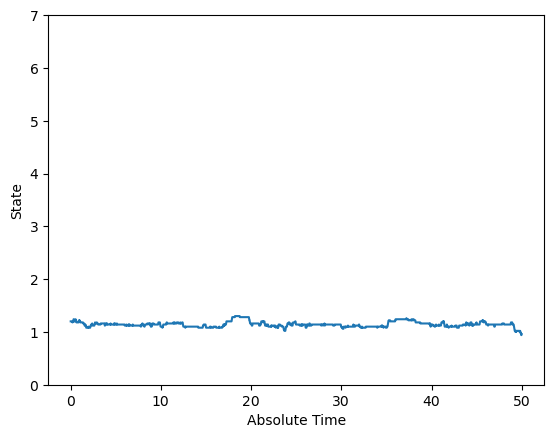

In [90]:
# Backward Constrained just 
t_prime_value = 50
delta = 0.02
current_state = states[T,0,0]
print(current_state)
terminal_state = np.arange(current_state-t_prime_value*delta,current_state+t_prime_value*delta,delta).reshape(-1,1)
terminal_state = np.clip(terminal_state, 0, 7, out=terminal_state)
best_prev = []
states_prev = terminal_state
for t in np.arange(t_prime_value,delta,-delta):
    curr_time = T+1+t
    # print(curr_time)
    time_emb = time_embedding_np(np.ones(states_prev.shape[0])*curr_time, tdim=50)
    features = np.hstack([states_prev,time_emb])
    score_value = rf_value.predict(features)
    score_action = rf_action.predict(features)
    score = score_action+score_value
    bext_idx_value = np.argmax(score)
    best_at_t = states_prev[bext_idx_value]
    best_prev.append(best_at_t)
    print(curr_time,best_at_t)
    # print(score)
    current_state = best_at_t
    states_prev = np.array([current_state-delta,current_state,current_state+delta]).reshape(-1,1)
    # states_prev = np.arange(current_state-(curr_time-1)*delta,current_state+(curr_time-1)*delta,delta).reshape(-1,1)
    # print(states_prev.shape)
    states_prev = np.clip(states_prev, 0, 7, out=states_prev)
plt.plot(np.arange(delta,t_prime_value,delta),list(reversed(best_prev)))
plt.yticks([0,1,2,3,4,5,6,7])
plt.xlabel('Absolute Time')
plt.ylabel('State')

([<matplotlib.axis.YTick at 0x382eee170>,
 [Text(0, 0, '0'),
  Text(0, 1, '1'),
  Text(0, 2, '2'),
  Text(0, 3, '3'),
  Text(0, 4, '4'),
  Text(0, 5, '5'),
  Text(0, 6, '6'),
  Text(0, 7, '7')])

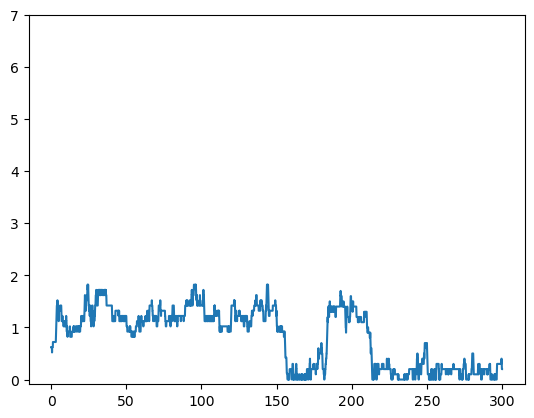

In [91]:
## Forward
t_prime_value = 300
delta = 0.1
current_state = states[T,0,0]
best_next = [current_state]
states_prev = terminal_state
for t in np.arange(0,t_prime_value,delta):
    curr_time = T+1+t
    states_next = np.array([current_state-delta,current_state,current_state+delta]).reshape(-1,1)
    states_next = np.clip(states_next, 0, 7, out=states_next)
    time_emb = time_embedding_np(np.ones(states_next.shape[0])*curr_time, tdim=50)
    features = np.hstack([states_next,time_emb])
    score_value = rf_value.predict(features)
    score_action = rf_action.predict(features)
    score = score_action+score_value
    bext_idx_value = np.argmax(score)
    best_at_t = states_next[bext_idx_value]
    best_next.append(best_at_t.item())
    # print(curr_time,best_at_t)
    current_state = best_at_t
plt.plot(np.arange(0,t_prime_value+delta,delta),best_next)
plt.yticks([0,1,2,3,4,5,6,7])

# Another Approximation method

### Backward break ties

In [29]:
def get_candidates(state, t, delta):
    next_state = [state - delta, state, state + delta]
    if next_state[0] < 0:
        return [state + delta, 0]
    elif next_state[-1] > 7:
        return [state - delta, state]
    else:
        return next_state

def contains_close(lst, x, atol=1e-12):
    for y in lst:
        if np.isclose(y, x, atol=atol):
            return True
    return False

def get_predecessors(state, t, delta, low=0.0, high=7.0, atol=1e-12):
    # Candidate predecessors (inverse of +/-delta,0 moves), then filter by forward legality
    # prev in [0,7] and state \in get_candidates(prev, t, delta)
    candidates = [state + delta, state, state - delta]
    preds = []
    for prev in candidates:
        if prev < low - atol or prev > high + atol:
            continue
        # Only accept prev if forward from prev can produce `state` (respecting your boundary behavior)
        forward_nexts = get_candidates(prev, t, delta)
        if contains_close(forward_nexts, state, atol=atol):
            preds.append(prev)
    #in case boundaries produce duplicates
    # Use rounding to the grid defined by delta to stabilize
    if preds:
        # round to nearest grid point on the delta lattice
        rpreds = []
        for p in preds:
            # snap to grid to avoid 1e-16 drift
            # snapped = np.clip(round((p - low) / delta) * delta + low, low, high)
            if not contains_close(rpreds, p, atol=atol):
                rpreds.append(p)
        preds = rpreds
    return preds

def enumerate_paths_cont_backward(x0, xT, t_initial=0, t_prime=20, delta=0.001, atol=1e-12,filter = False):
    """
    Build all paths length t_prime that end at xT (terminal), then reverse them and
    keep only those that start at x0 (initial). Output rows go from t=t_initial..t_initial+t_prime.
    """
    # Build backward: layers are times t = t_initial+t_prime-1, ..., t_initial
    paths_back = [[xT]]  # each path grows backward: [..., s_{t-1}, s_t==xT]
    for k in range(t_prime):
        t = t_initial + (t_prime - 1 - k)  # backward step's corresponding forward-time index
        new_paths = []
        for path in paths_back:
            curr = path[0]  # current layer's (forward) "next" state at time t+1
            preds = get_predecessors(curr, t, delta, atol=atol)
            for prev in preds:
                new_paths.append([prev] + path)
        paths_back = new_paths

    # Now each path is [s_0, s_1, ..., s_tprime] but *not* guaranteed to start at x0
    # Filter: keep only those where s_0 == x0 (within tolerance)
    if filter: 
        filtered = []
        for p in paths_back:
            if np.isclose(p[0], x0, atol=atol) and np.isclose(p[-1], xT, atol=atol):
                # (Optional) snap all states to the delta grid to tidy floats
                # p_snapped = [round((s - 0.0) / delta) * delta for s in p]
                # # clamp to [0,7] just in case of rounding wobble
                # p_snapped = [float(np.clip(s, 0.0, 7.0)) for s in p_snapped]
                filtered.append(p)
    else:
        filtered = []
        for p in paths_back:
            filtered.append(p)
    # Convert to DataFrame: columns t=t_initial..t_initial+t_prime
    cols = [f"t={t_initial + delta*i}" for i in range(t_prime + 1)]
    df = pd.DataFrame(filtered, columns=cols)
    return df


In [412]:
df_all_paths = enumerate_paths_cont_backward(x0=0.71, xT = 1.41, t_initial = 100,t_prime = 10,delta = 0.1,filter = True)
df_all_paths

,t=100.0,t=100.1,t=100.2,t=100.3,t=100.4,t=100.5,t=100.6,t=100.7,t=100.8,t=100.9,t=101.0
0,0.71,0.81,0.91,1.01,1.11,1.21,1.31,1.41,1.51,1.51,1.41
1,0.71,0.81,0.91,1.01,1.11,1.21,1.31,1.41,1.41,1.51,1.41
2,0.71,0.81,0.91,1.01,1.11,1.21,1.31,1.31,1.41,1.51,1.41
3,0.71,0.81,0.91,1.01,1.11,1.21,1.21,1.31,1.41,1.51,1.41
4,0.71,0.81,0.91,1.01,1.11,1.11,1.21,1.31,1.41,1.51,1.41
...,...,...,...,...,...,...,...,...,...,...,...
205,0.71,0.81,0.71,0.71,0.81,0.91,1.01,1.11,1.21,1.31,1.41
206,0.71,0.71,0.71,0.71,0.81,0.91,1.01,1.11,1.21,1.31,1.41
207,0.71,0.61,0.71,0.71,0.81,0.91,1.01,1.11,1.21,1.31,1.41
208,0.71,0.71,0.61,0.71,0.81,0.91,1.01,1.11,1.21,1.31,1.41


In [4]:
gamma = 0.90
T = 3000
delta = 0.3
n= int(T/delta)
print(n)
seed = np.random.choice(np.arange(0,100),size = 1)
actions, states, irewards, times = simulate_data_count(rewards_in_period,delta,
                                                       session_duration = 500000,tdim=50, 
                                                       n_sessions=1,seed = 515+seed)

prewards = make_weighted_target(irewards, gamma,T = n,normalization = False)
X_train_oh = states[:n,0,:]
# X_train_oh = np.hstack([position_encoder(states[:n,0,0], type="onehot"), states[:n,0,1:]])
print(X_train_oh.shape)
Y_train_action = irewards[:n]
Y_train_value = prewards[:n]

rf_value = xgb.XGBRegressor(
    objective="reg:squarederror",
    tree_method="exact", 
    n_jobs = -1,
    learning_rate=0.05, max_depth=10,
    subsample=1, colsample_bytree=0.8,
    n_estimators=2000, eval_metric="rmse")
rf_value.fit(X_train_oh, Y_train_value)

rf_action = xgb.XGBRegressor(
    objective="reg:squarederror",
    tree_method="exact", 
    n_jobs = -1,
    learning_rate=0.05, max_depth=10,
    subsample=1, colsample_bytree=0.8,
    n_estimators=2000, eval_metric="rmse")
rf_action.fit(X_train_oh, Y_train_action)


10000
(10000, 51)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric='rmse', feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=10,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=2000,
             n_jobs=-1, num_parallel_tree=None, ...)

In [ ]:
delta = 0.3
step_prime = 12
t_prime = step_prime * delta
T = T+20
DELTA_T = 40
# current_state = round(states[T,0,0],2)
current_state = 2.6
print(T,current_state)
future_states = [current_state]
for delta_t in np.arange(0,DELTA_T,delta):
    terminal_state_cands = np.arange(current_state-step_prime*delta,current_state+step_prime*delta,delta).reshape(-1,1)
    terminal_state_cands = np.clip(terminal_state_cands, 0, 7, out=terminal_state_cands)
    curr_time = T+delta_t+1+t_prime
    # print(curr_time-1)
    # print(min(terminal_state_cands),max(terminal_state_cands))
    time_emb = time_embedding_np(np.ones(terminal_state_cands.shape[0])*curr_time, tdim=50)
    features = np.hstack([terminal_state_cands,time_emb])
    score_value = rf_value.predict(features)
    score_action = rf_action.predict(features)
    score = score_action+score_value
    bext_idx_value = np.argmax(score)
    best_at_terminal = terminal_state_cands[bext_idx_value].item()
    print(curr_time,best_at_terminal)
    df_all_paths = enumerate_paths_cont_backward(x0=current_state,xT = best_at_terminal, t_initial = T+delta_t,t_prime = step_prime,delta = delta,filter = True)
    print(df_all_paths.shape)
    n_paths = df_all_paths.shape[0]
    irewards_pred = np.zeros((n_paths,  step_prime+1))

    for i in np.arange(0,round(t_prime+delta,2),delta):
        i_idx = int(i/delta)
        # print(i_idx)
        next_state = np.array(df_all_paths.iloc[:,i_idx]).reshape(-1,1)
        curr_time = T+delta_t+i+1
        time_emb = time_embedding_np(np.ones(next_state.shape[0])*curr_time, tdim=50).reshape(-1,50)
        features = np.hstack([next_state,time_emb])
        # np.hstack([position_encoder(next_state, type="onehot"), time_emb])
        # np.hstack([next_state,time_emb])
        irewards_pred[:,i_idx] = rf_action.predict(features)
    # # Convert to DataFrame for inspection
    reward_cols = [f"t={T+delta_t+t}" for t in np.arange(0,round(t_prime+delta,3),delta)]
    df_ireward = pd.DataFrame(irewards_pred, columns=reward_cols)
    next_state = np.array(df_all_paths.iloc[:,-1]).reshape(-1,1)
    curr_time = T+1+t_prime
    time_emb = time_embedding_np(np.ones(next_state.shape[0])*curr_time, tdim=50).reshape(-1,50)
    # print(next_state.shape,time_emb.shape)
    features = np.hstack([next_state,time_emb])
    # np.hstack([position_encoder(next_state, type="onehot"), time_emb])
    # np.hstack([next_state,time_emb])
    prewards_pred = rf_value.predict(features)
    df_ireward[f"preward"] = prewards_pred
    rewards_matrix = df_ireward.iloc[:, 1:].values
    discounts = gamma ** np.arange(0, step_prime+1)

    # Compute discounted total reward per path
    discounted_returns = rewards_matrix * discounts  
    total_discounted = discounted_returns.sum(axis=1)
    # print(total_discounted)
    bext_idx = np.argmax(total_discounted)
    next_state = df_all_paths.iloc[bext_idx,1].item()
    future_states.append(next_state)
    current_state = next_state
    print(T+delta_t+delta,current_state)


3020 2.7
3024.6 1.2000000000000008
(16236, 13)
3020.3 2.4
3024.9 1.2000000000000006
(28314, 13)
3020.6000000000004 2.1
3025.2 1.2000000000000008
(43252, 13)
3020.9 1.7999999999999998
3025.5 1.5000000000000007
(69576, 13)
3021.2000000000003 1.7999999999999998
3025.7999999999997 1.5000000000000007
(69576, 13)
3021.5 1.7999999999999998
3026.1 4.200000000000001
(1221, 13)
3021.8 1.7999999999999998
3026.4 4.800000000000001
(78, 13)
3022.1000000000004 1.5
3026.7 4.800000000000002
(12, 13)
3022.4 1.7999999999999998
3027.0 4.800000000000001
(78, 13)
3022.7000000000003 1.7999999999999998
3027.2999999999997 5.100000000000001
(12, 13)
3023.0 1.7999999999999998
3027.6 5.100000000000001
(12, 13)
3023.3 1.7999999999999998
3027.9 5.100000000000001
(12, 13)
3023.6000000000004 1.7999999999999998
3028.2 5.100000000000001
(12, 13)
3023.9 1.7999999999999998
3028.5 5.100000000000001
(12, 13)
3024.2000000000003 1.7999999999999998
3028.7999999999997 5.100000000000001
(12, 13)
3024.5 1.7999999999999998
3029.1

KeyboardInterrupt: 

In [7]:
delta = 0.3
step_prime = 14
stpe_prime_value= 14
t_prime = step_prime * delta
T = 3032
DELTA_T = 28
# current_state = round(states[T,0,0],2)
current_state = 5.8
print(T,current_state)
future_states = [current_state]
for delta_t in np.arange(0,DELTA_T,delta):
    terminal_state_cands = np.arange(current_state-step_prime*delta,current_state+step_prime*delta,delta).reshape(-1,1)
    terminal_state_cands = np.clip(terminal_state_cands, 0, 7, out=terminal_state_cands)
    curr_time = T+delta_t+1+t_prime
    # print(curr_time-1)
    # print(min(terminal_state_cands),max(terminal_state_cands))
    time_emb = time_embedding_np(np.ones(terminal_state_cands.shape[0])*curr_time, tdim=50)
    features = np.hstack([terminal_state_cands,time_emb])
    score_value = rf_value.predict(features)
    score_action = rf_action.predict(features)
    score = score_action+score_value
    bext_idx_value = np.argmax(score)
    best_at_terminal = terminal_state_cands[bext_idx_value].item()
    print(curr_time,best_at_terminal)
    df_all_paths = enumerate_paths_cont_backward(x0=current_state,xT = best_at_terminal, t_initial = T+delta_t,t_prime = stpe_prime_value,delta = delta,filter = True)
    print(df_all_paths.shape)
    n_paths = df_all_paths.shape[0]
    irewards_pred = np.zeros((n_paths,  step_prime+1))

    for i_idx in np.arange(0,step_prime+1,1):
        next_state = np.array(df_all_paths.iloc[:,i_idx]).reshape(-1,1)
        curr_time = T+delta_t+i_idx*delta+1
        time_emb = time_embedding_np(np.ones(next_state.shape[0])*curr_time, tdim=50).reshape(-1,50)
        features = np.hstack([next_state,time_emb])
        # np.hstack([position_encoder(next_state, type="onehot"), time_emb])
        # np.hstack([next_state,time_emb])
        irewards_pred[:,i_idx] = rf_action.predict(features)
    # # Convert to DataFrame for inspection
    reward_cols = [f"t={T+delta_t+idx*delta}" for idx in np.arange(0,step_prime+1,1)]
    df_ireward = pd.DataFrame(irewards_pred, columns=reward_cols)
    next_state = np.array(df_all_paths.iloc[:,-1]).reshape(-1,1)
    curr_time = T+1+t_prime
    time_emb = time_embedding_np(np.ones(next_state.shape[0])*curr_time, tdim=50).reshape(-1,50)
    # print(next_state.shape,time_emb.shape)
    features = np.hstack([next_state,time_emb])
    # np.hstack([position_encoder(next_state, type="onehot"), time_emb])
    # np.hstack([next_state,time_emb])
    prewards_pred = rf_value.predict(features)
    df_ireward[f"preward"] = prewards_pred
    rewards_matrix = df_ireward.iloc[:, 1:].values
    discounts = gamma ** np.arange(0, step_prime+1)

    # Compute discounted total reward per path
    discounted_returns = rewards_matrix * discounts  
    total_discounted = discounted_returns.sum(axis=1)
    # print(total_discounted)
    bext_idx = np.argmax(total_discounted)
    next_state = round(df_all_paths.iloc[bext_idx,1].item(),3)
    future_states.append(next_state)
    current_state = next_state
    print(T+delta_t+delta,current_state)


3032 5.8
3037.2 2.5
(546, 15)
3032.3 5.8
3037.5 2.5
(546, 15)
3032.6000000000004 5.8
3037.7999999999997 2.5
(546, 15)
3032.9 5.8
3038.1 3.0999999999999996
(7098, 15)
3033.2000000000003 5.8
3038.3999999999996 3.0999999999999996
(7098, 15)
3033.5 5.8
3038.7 3.0999999999999996
(7098, 15)
3033.8 5.8
3039.0 2.5
(546, 15)
3034.1000000000004 5.8
3039.2999999999997 2.5
(546, 15)
3034.4 5.8
3039.6 2.5
(546, 15)
3034.7000000000003 5.5
3039.8999999999996 1.5999999999999999
(14, 15)
3035.0 5.2
3040.2 1.6
(105, 15)
3035.3 5.2
3040.5 1.6
(105, 15)
3035.6000000000004 5.2
3040.7999999999997 1.9000000000000001
(546, 15)
3035.9 5.2
3041.1 1.6
(105, 15)
3036.2000000000003 5.2
3041.3999999999996 1.6
(105, 15)
3036.5 5.2
3041.7 1.3
(14, 15)
3036.8 5.2
3042.0 1.3
(14, 15)
3037.1000000000004 4.9
3042.2999999999997 1.6000000000000003
(546, 15)
3037.4 4.6
3042.6 1.5999999999999996
(2184, 15)
3037.7000000000003 4.3
3042.8999999999996 1.5999999999999996
(7098, 15)
3038.0 4.0
3043.2 1.5999999999999996
(19383, 15)

KeyboardInterrupt: 

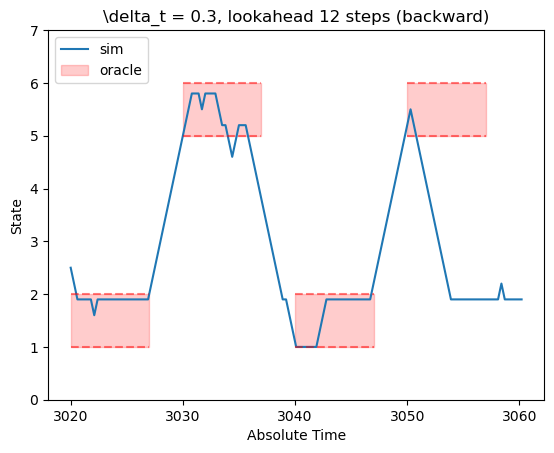

In [ ]:
plt.plot(np.arange(T,T+DELTA_T+delta,delta),future_states,label = 'sim')
plt.xticks(np.arange(T,T+DELTA_T+10,10))
plt.fill_between(np.arange(3030,3038,1),np.ones(8)*5,np.ones(8)*6,color = 'red',alpha = 0.2,label = 'oracle')
plt.fill_between(np.arange(3050,3058,1),np.ones(8)*5,np.ones(8)*6,color = 'red',alpha = 0.2)
# plt.fill_between(np.arange(3070,3078,1),np.ones(8)*5,np.ones(8)*6,color = 'red',alpha = 0.2)
plt.fill_between(np.arange(3020,3028,1),np.ones(8)*1,np.ones(8)*2,color = 'red',alpha = 0.2)
plt.fill_between(np.arange(3040,3048,1),np.ones(8)*1,np.ones(8)*2,color = 'red',alpha = 0.2)
# plt.fill_between(np.arange(3060,3068,1),np.ones(8)*1,np.ones(8)*2,color = 'red',alpha = 0.2)
plt.hlines(y = 6, xmin = 3030, xmax = 3037,color = 'r',linestyles= '--',alpha = 0.5)
plt.hlines(y = 5, xmin = 3030, xmax = 3037,color = 'r',linestyles= '--',alpha = 0.5)
plt.hlines(y = 6, xmin = 3050, xmax = 3057,color = 'r',linestyles= '--',alpha = 0.5)
plt.hlines(y = 5, xmin = 3050, xmax = 3057,color = 'r',linestyles= '--',alpha = 0.5)
# plt.hlines(y = 5, xmin = 3070, xmax = 3077,color = 'r',linestyles= '--',alpha = 0.5)
plt.hlines(y = 1, xmin = 3020, xmax = 3027,color = 'r',linestyles= '--',alpha = 0.5)
plt.hlines(y = 2, xmin = 3020, xmax = 3027,color = 'r',linestyles= '--',alpha = 0.5)
plt.hlines(y = 1, xmin = 3040, xmax = 3047,color = 'r',linestyles= '--',alpha = 0.5)
plt.hlines(y = 2, xmin = 3040, xmax = 3047,color = 'r',linestyles= '--',alpha = 0.5)
# plt.hlines(y = 2, xmin = 3060, xmax = 3067,color = 'r',linestyles= '--',alpha = 0.5)
plt.yticks([0,1,2,3,4,5,6,7])
plt.xlabel('Absolute Time')
plt.ylabel('State')
plt.title('\delta_t = 0.3, lookahead 14 steps (backward)')
plt.legend()

In [320]:
time_emb.shape

(2913900, 1)

### Forwardly just increase depths greedily

In [ ]:
delta = 0.3
step_prime = 20
stpe_prime_value= 10
t_prime = step_prime * delta
T = T+20
DELTA_T = 40
k = 5 
# current_state = round(states[T,0,0],2)
current_state = 2.5
print(T,current_state)
future_states = [current_state]
for delta_t in np.arange(0,DELTA_T,delta):
    terminal_state_cands = np.arange(current_state-step_prime*delta,current_state+step_prime*delta,delta).reshape(-1,1)
    terminal_state_cands = np.clip(terminal_state_cands, 0, 7, out=terminal_state_cands)
    curr_time = T+delta_t+1+t_prime
    # print(curr_time-1)
    # print(min(terminal_state_cands),max(terminal_state_cands))
    time_emb = time_embedding_np(np.ones(terminal_state_cands.shape[0])*curr_time, tdim=50)
    features = np.hstack([terminal_state_cands,time_emb])
    score_value = rf_value.predict(features)
    score_action = rf_action.predict(features)
    score = score_action+score_value
    bext_idx_value = np.argmax(score)
    best_at_terminal = terminal_state_cands[bext_idx_value].item()
    print(curr_time,best_at_terminal)
    df_all_paths = enumerate_paths_cont_backward(x0=current_state,xT = best_at_terminal, t_initial = T+delta_t+stpe_prime_value,t_prime = stpe_prime_value,delta = delta,filter = False)
    print(df_all_paths.shape)
    n_paths = df_all_paths.shape[0]
    irewards_pred = np.zeros((n_paths,  step_prime+1))

    for i_idx in np.arange(0,step_prime+1,1):
        next_state = np.array(df_all_paths.iloc[:,i_idx]).reshape(-1,1)
        curr_time = T+delta_t+stpe_prime_value+i_idx*delta+1
        time_emb = time_embedding_np(np.ones(next_state.shape[0])*curr_time, tdim=50).reshape(-1,50)
        features = np.hstack([next_state,time_emb])
        # np.hstack([position_encoder(next_state, type="onehot"), time_emb])
        # np.hstack([next_state,time_emb])
        irewards_pred[:,i_idx] = rf_action.predict(features)
    # # Convert to DataFrame for inspection
    reward_cols = [f"t={T+delta_t+idx*delta}" for idx in np.arange(0,step_prime+1,1)]
    df_ireward = pd.DataFrame(irewards_pred, columns=reward_cols)
    next_state = np.array(df_all_paths.iloc[:,-1]).reshape(-1,1)
    curr_time = T+1+t_prime
    time_emb = time_embedding_np(np.ones(next_state.shape[0])*curr_time, tdim=50).reshape(-1,50)
    # print(next_state.shape,time_emb.shape)
    features = np.hstack([next_state,time_emb])
    # np.hstack([position_encoder(next_state, type="onehot"), time_emb])
    # np.hstack([next_state,time_emb])
    prewards_pred = rf_value.predict(features)
    df_ireward[f"preward"] = prewards_pred
    rewards_matrix = df_ireward.iloc[:, 1:].values
    discounts = gamma ** np.arange(0, step_prime+1)

    # Compute discounted total reward per path
    discounted_returns = rewards_matrix * discounts  
    total_discounted = discounted_returns.sum(axis=1)
    # print(total_discounted)

    part = np.argpartition(total_discounted, -k)[-k:]          # k largest, unsorted
    topk_idx = part[np.argsort(-total_discounted[part])]       # sort those k
    prev_states = df_all_paths.iloc[topk_idx,1]

    
    paths_list = []
    for pre_state in prev_states:
        df_all_paths = enumerate_paths_cont_backward(x0=current_state,xT = pre_state, t_initial = T+delta_t,t_prime = stpe_prime_value,delta = delta,filter = True)
        paths_list.append(df_all_paths)
    DF_ALL_PATHS = pd.concat(paths_list, ignore_index=True, copy=False)
    DF_ALL_PATHS = DF_ALL_PATHS.drop_duplicates(ignore_index=True)
    
    for i_idx in np.arange(0,step_prime+1,1):
        next_state = np.array(df_all_paths.iloc[:,i_idx]).reshape(-1,1)
        curr_time = T+delta_t+i_idx*delta+1
        time_emb = time_embedding_np(np.ones(next_state.shape[0])*curr_time, tdim=50).reshape(-1,50)
        features = np.hstack([next_state,time_emb])
        # np.hstack([position_encoder(next_state, type="onehot"), time_emb])
        # np.hstack([next_state,time_emb])
        irewards_pred[:,i_idx] = rf_action.predict(features)
    # # Convert to DataFrame for inspection
    reward_cols = [f"t={T+delta_t+idx*delta}" for idx in np.arange(0,step_prime+1,1)]
    df_ireward = pd.DataFrame(irewards_pred, columns=reward_cols)
    next_state = np.array(df_all_paths.iloc[:,-1]).reshape(-1,1)
    curr_time = T+1+stpe_prime_value * delta
    time_emb = time_embedding_np(np.ones(next_state.shape[0])*curr_time, tdim=50).reshape(-1,50)
    # print(next_state.shape,time_emb.shape)
    features = np.hstack([next_state,time_emb])
    # np.hstack([position_encoder(next_state, type="onehot"), time_emb])
    # np.hstack([next_state,time_emb])
    prewards_pred = rf_value.predict(features)
    df_ireward[f"preward"] = prewards_pred
    rewards_matrix = df_ireward.iloc[:, 1:].values
    discounts = gamma ** np.arange(0, step_prime+1)

    # Compute discounted total reward per path
    discounted_returns = rewards_matrix * discounts  
    total_discounted = discounted_returns.sum(axis=1)
    bext_idx = np.argmax(total_discounted)
    next_state = round(df_all_paths.iloc[bext_idx,1].item(),3)
    future_states.append(next_state)
    current_state = next_state
    print(T+delta_t+delta,current_state)
